# EDA 18: Order Count Over Time Analysis

This notebook analyzes order count over time and decomposes revenue movement into order-volume and average-order-value signals using `orders.csv`, `order_items.csv`, and `payments.csv`.

Forecast-feature examples are leakage-safe: lagged and rolling order-count features use only historical values available before the forecast date.

## 1. Setup and file discovery

Locate the required CSV files recursively from the current working directory. Missing files are reported clearly and dependent sections continue where possible.

In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

ROOT = Path.cwd()
REQUIRED_FILES = ["orders.csv", "order_items.csv", "payments.csv"]

def normalize_name(value):
    return re.sub(r"[^a-z0-9]+", "", str(value).strip().lower())

def display_warning(message):
    print(f"WARNING: {message}")

def find_csv_files(root, filenames):
    all_csvs = list(root.rglob("*.csv"))
    found = {}
    for filename in filenames:
        target = normalize_name(filename)
        matches = [p for p in all_csvs if normalize_name(p.name) == target]
        matches = sorted(matches, key=lambda p: (len(p.parts), str(p).lower()))
        found[filename] = matches[0] if matches else None
    return found

file_paths = find_csv_files(ROOT, REQUIRED_FILES)
discovery_table = pd.DataFrame(
    {
        "file": list(file_paths.keys()),
        "path": [str(p) if p is not None else None for p in file_paths.values()],
        "status": ["found" if p is not None else "missing" for p in file_paths.values()],
    }
)
display(discovery_table)

for name, path in file_paths.items():
    if path is None:
        display_warning(f"{name} was not found. Dependent analysis will continue where possible.")

,file,path,status
0,orders.csv,D:\Code\Datathon 2026\datathon-2026-round-1\or...,found
1,order_items.csv,D:\Code\Datathon 2026\datathon-2026-round-1\or...,found
2,payments.csv,D:\Code\Datathon 2026\datathon-2026-round-1\pa...,found


## 2. Load orders, order_items, and payments

Available files are loaded safely with pandas. Basic schema and sample rows are displayed for transparency.

In [2]:
def safe_read_csv(path):
    if path is None:
        return None
    attempts = [
        {"low_memory": False},
        {"encoding": "utf-8-sig", "low_memory": False},
        {"encoding": "latin1", "low_memory": False},
    ]
    last_error = None
    for kwargs in attempts:
        try:
            return pd.read_csv(path, **kwargs)
        except Exception as exc:
            last_error = exc
    display_warning(f"Could not load {path}: {last_error}")
    return None

data = {name: safe_read_csv(path) for name, path in file_paths.items()}
orders = data.get("orders.csv")
order_items = data.get("order_items.csv")
payments = data.get("payments.csv")

load_summary = []
for name, df in data.items():
    load_summary.append(
        {
            "file": name,
            "loaded": df is not None,
            "rows": 0 if df is None else len(df),
            "columns": 0 if df is None else df.shape[1],
        }
    )
display(pd.DataFrame(load_summary))

for name, df in data.items():
    if df is not None:
        print(f"\n{name} columns:")
        print(list(df.columns))
        display(df.head())

,file,loaded,rows,columns
0,orders.csv,True,646945,8
1,order_items.csv,True,714669,7
2,payments.csv,True,646945,4



orders.csv columns:
['order_id', 'order_date', 'customer_id', 'zip', 'order_status', 'payment_method', 'device_type', 'order_source']


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign



order_items.csv columns:
['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount', 'promo_id', 'promo_id_2']


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,"1,138.2200",0.0000,NaN,NaN
1,2,609,7,"10,166.2500",0.0000,NaN,NaN
2,3,396,3,"11,220.3300",0.0000,NaN,NaN
3,4,635,5,"10,639.2500",0.0000,NaN,NaN
4,6,1935,1,"1,597.8400",0.0000,NaN,NaN



payments.csv columns:
['order_id', 'payment_method', 'payment_value', 'installments']


,order_id,payment_method,payment_value,installments
0,1,credit_card,"7,967.5400",3
1,2,cod,"71,163.7500",1
2,3,credit_card,"33,660.9900",3
3,4,credit_card,"53,196.2500",3
4,6,paypal,"1,597.8400",1


## 3. Identify key, date, revenue, payment, and item columns

Column detection handles case, spacing, underscores, and common synonyms. Revenue is inferred from item price × quantity minus discount when direct revenue is unavailable.

In [3]:
def score_column(col, include_terms=None, exclude_terms=None):
    n = normalize_name(col)
    score = 0
    include_terms = include_terms or []
    exclude_terms = exclude_terms or []
    for term, points in include_terms:
        if normalize_name(term) in n:
            score += points
    for term, points in exclude_terms:
        if normalize_name(term) in n:
            score -= points
    return score

def choose_column_by_terms(df, include_terms, exclude_terms=None, min_score=1):
    if df is None or df.empty:
        return None
    scored = [(score_column(col, include_terms, exclude_terms), col) for col in df.columns]
    scored = sorted(scored, key=lambda x: (x[0], -len(str(x[1]))), reverse=True)
    return scored[0][1] if scored and scored[0][0] >= min_score else None

def choose_numeric_column(df, include_terms, exclude_terms=None, min_score=1):
    if df is None or df.empty:
        return None
    scored = []
    for col in df.columns:
        numeric = pd.to_numeric(df[col], errors="coerce")
        valid_rate = numeric.notna().mean()
        if valid_rate < 0.5 or numeric.nunique(dropna=True) < 2:
            continue
        score = score_column(col, include_terms, exclude_terms) + valid_rate * 3
        scored.append((score, col))
    scored = sorted(scored, reverse=True)
    return scored[0][1] if scored and scored[0][0] >= min_score else None

def choose_date_column(df, preferred_terms=None):
    if df is None or df.empty:
        return None
    preferred_terms = preferred_terms or []
    candidates = []
    for col in df.columns:
        parsed = pd.to_datetime(df[col], errors="coerce")
        valid_rate = parsed.notna().mean()
        unique_count = parsed.nunique(dropna=True)
        name_score = score_column(
            col,
            preferred_terms + [("date", 10), ("time", 4), ("order", 5), ("created", 4)],
            [("id", 8), ("zip", 8), ("price", 8), ("amount", 8), ("quantity", 8), ("qty", 8)],
        )
        if valid_rate >= 0.45 and unique_count >= 1:
            candidates.append((valid_rate * 100 + name_score + min(unique_count, 100) * 0.01, col))
    candidates = sorted(candidates, reverse=True)
    return candidates[0][1] if candidates else None

def choose_common_key(left_df, right_df, left_terms, right_terms=None):
    if left_df is None or right_df is None:
        return None, None
    right_terms = right_terms or left_terms
    left_candidates = [
        col for col in left_df.columns
        if score_column(col, left_terms, [("date", 5), ("amount", 5), ("price", 5), ("quantity", 5), ("qty", 5)]) > 0
    ]
    right_candidates = [
        col for col in right_df.columns
        if score_column(col, right_terms, [("date", 5), ("amount", 5), ("price", 5), ("quantity", 5), ("qty", 5)]) > 0
    ]
    best = None
    for lcol in left_candidates:
        lvals = left_df[lcol].dropna().astype(str)
        if lvals.empty:
            continue
        lsample = set(lvals.head(10000))
        for rcol in right_candidates:
            rvals = right_df[rcol].dropna().astype(str)
            if rvals.empty:
                continue
            rsample = set(rvals.head(10000))
            overlap = len(lsample.intersection(rsample))
            score = overlap + score_column(lcol, left_terms) + score_column(rcol, right_terms)
            if best is None or score > best[0]:
                best = (score, lcol, rcol, overlap)
    if best is None or best[0] <= 0:
        return None, None
    return best[1], best[2]

order_terms = [("orderid", 14), ("order", 8), ("invoice", 6), ("transaction", 6), ("receipt", 4)]
product_terms = [("productid", 14), ("product", 8), ("sku", 6), ("itemid", 8), ("item", 4)]

order_id_col = choose_column_by_terms(orders, order_terms, [("date", 6), ("amount", 4), ("status", 3)], min_score=4)
order_date_col = choose_date_column(orders, [("orderdate", 16), ("order", 8)])
item_order_col, order_order_col_for_items = choose_common_key(order_items, orders, order_terms)
payment_order_col, order_order_col_for_payments = choose_common_key(payments, orders, order_terms)
product_col = choose_column_by_terms(order_items, product_terms, [("price", 5), ("amount", 5)], min_score=4)

quantity_col = choose_numeric_column(order_items, [("quantity", 10), ("qty", 10), ("units", 6)], [("id", 10), ("price", 6), ("amount", 4)], min_score=5)
price_col = choose_numeric_column(order_items, [("unitprice", 12), ("price", 10), ("sellingprice", 10), ("saleprice", 10)], [("id", 10), ("cost", 8), ("discount", 8), ("quantity", 8), ("qty", 8)], min_score=5)
discount_col = choose_numeric_column(order_items, [("discount", 10), ("promo", 3)], [("id", 5), ("quantity", 8), ("qty", 8), ("price", 5)], min_score=5)
direct_order_revenue_col = choose_numeric_column(
    orders,
    [("revenue", 12), ("sales", 10), ("amount", 8), ("total", 8), ("subtotal", 6), ("net", 6), ("ordervalue", 10)],
    [("discount", 10), ("price", 8), ("cost", 8), ("quantity", 10), ("qty", 10), ("id", 10), ("zip", 10)],
    min_score=5,
)
direct_item_revenue_col = choose_numeric_column(
    order_items,
    [("revenue", 12), ("sales", 10), ("total", 8), ("subtotal", 6), ("net", 6)],
    [("discount", 10), ("price", 8), ("cost", 8), ("quantity", 10), ("qty", 10), ("id", 10)],
    min_score=5,
)
payment_amount_col = choose_numeric_column(
    payments,
    [("paymentvalue", 14), ("paymentamount", 12), ("amount", 9), ("value", 8), ("paid", 6), ("total", 6)],
    [("id", 8), ("installment", 8), ("quantity", 8), ("qty", 8)],
    min_score=5,
)
payment_status_col = choose_column_by_terms(payments, [("status", 10), ("state", 5)], [("id", 8), ("amount", 8), ("value", 8)], min_score=5)

detected = pd.DataFrame(
    [
        {"field": "orders.order_id", "column": order_id_col},
        {"field": "orders.order_date", "column": order_date_col},
        {"field": "order_items.order_id", "column": item_order_col},
        {"field": "payments.order_id", "column": payment_order_col},
        {"field": "order_items.product_id", "column": product_col},
        {"field": "order_items.quantity", "column": quantity_col},
        {"field": "order_items.price", "column": price_col},
        {"field": "order_items.discount", "column": discount_col},
        {"field": "orders.direct_revenue", "column": direct_order_revenue_col},
        {"field": "order_items.direct_revenue", "column": direct_item_revenue_col},
        {"field": "payments.payment_amount", "column": payment_amount_col},
        {"field": "payments.payment_status", "column": payment_status_col},
    ]
)
display(detected)

required_ready = True
if orders is None:
    display_warning("orders.csv is required for order-count analysis.")
    required_ready = False
if order_id_col is None:
    display_warning("Could not identify order ID.")
    required_ready = False
if order_date_col is None:
    display_warning("Could not identify order date.")
    required_ready = False
if direct_order_revenue_col is None and direct_item_revenue_col is None and not (quantity_col is not None and price_col is not None) and payment_amount_col is None:
    display_warning("Could not identify or infer revenue from orders, order_items, or payments.")

,field,column
0,orders.order_id,order_id
1,orders.order_date,order_date
2,order_items.order_id,order_id
3,payments.order_id,order_id
4,order_items.product_id,product_id
5,order_items.quantity,quantity
6,order_items.price,unit_price
7,order_items.discount,discount_amount
8,orders.direct_revenue,None
9,order_items.direct_revenue,None


## 4. Build order-level dataset

Order-level revenue is built from the best available source. Item-derived revenue is preferred when item lines match orders well because it directly uses item quantity, price, and discounts; payment totals are used as validation or fallback.

In [4]:
order_level = pd.DataFrame()
item_agg = pd.DataFrame()
payment_agg = pd.DataFrame()
revenue_comparison = pd.DataFrame()
selected_revenue_source = "not available"
selected_revenue_reason = "No usable revenue source was identified."

if required_ready:
    orders_work = orders.copy()
    orders_work["_order_id"] = orders_work[order_id_col].astype(str)
    orders_work["order_date"] = pd.to_datetime(orders_work[order_date_col], errors="coerce")
    order_level = orders_work[["_order_id", "order_date"]].drop_duplicates("_order_id").copy()

    if direct_order_revenue_col is not None:
        order_level["orders_direct_revenue"] = pd.to_numeric(orders_work.drop_duplicates("_order_id")[direct_order_revenue_col], errors="coerce").values

    if order_items is not None and item_order_col is not None:
        items_work = order_items.copy()
        items_work["_order_id"] = items_work[item_order_col].astype(str)
        if direct_item_revenue_col is not None:
            items_work["item_revenue"] = pd.to_numeric(items_work[direct_item_revenue_col], errors="coerce")
        elif quantity_col is not None and price_col is not None:
            qty = pd.to_numeric(items_work[quantity_col], errors="coerce")
            price = pd.to_numeric(items_work[price_col], errors="coerce")
            discount = pd.to_numeric(items_work[discount_col], errors="coerce").fillna(0) if discount_col is not None else 0
            items_work["item_revenue"] = qty * price
        else:
            items_work["item_revenue"] = np.nan
        items_work["item_quantity"] = pd.to_numeric(items_work[quantity_col], errors="coerce") if quantity_col is not None else np.nan
        item_agg = items_work.groupby("_order_id", as_index=False).agg(
            item_revenue=("item_revenue", "sum"),
            item_count=("item_revenue", "size"),
            total_quantity=("item_quantity", "sum"),
        )
        order_level = order_level.merge(item_agg, on="_order_id", how="left")

    if payments is not None and payment_order_col is not None and payment_amount_col is not None:
        payments_work = payments.copy()
        payments_work["_order_id"] = payments_work[payment_order_col].astype(str)
        payments_work["payment_amount"] = pd.to_numeric(payments_work[payment_amount_col], errors="coerce")
        agg_spec = {"payment_amount": ("payment_amount", "sum"), "payment_records": ("payment_amount", "size")}
        if payment_status_col is not None:
            payments_work["payment_status"] = payments_work[payment_status_col].astype(str)
            agg_spec["payment_status_sample"] = ("payment_status", lambda s: ", ".join(sorted(set(s.dropna().astype(str)))[:3]))
        payment_agg = payments_work.groupby("_order_id", as_index=False).agg(**agg_spec)
        order_level = order_level.merge(payment_agg, on="_order_id", how="left")

    if "item_revenue" in order_level.columns and "payment_amount" in order_level.columns:
        comp = order_level[["item_revenue", "payment_amount"]].dropna().copy()
        if not comp.empty:
            comp["absolute_difference"] = (comp["item_revenue"] - comp["payment_amount"]).abs()
            comp["relative_difference"] = comp["absolute_difference"] / comp[["item_revenue", "payment_amount"]].abs().max(axis=1).replace(0, np.nan)
            revenue_comparison = pd.DataFrame(
                [
                    {
                        "overlapping_orders": len(comp),
                        "item_revenue_total": comp["item_revenue"].sum(),
                        "payment_amount_total": comp["payment_amount"].sum(),
                        "correlation": comp["item_revenue"].corr(comp["payment_amount"]),
                        "median_absolute_difference": comp["absolute_difference"].median(),
                        "median_relative_difference": comp["relative_difference"].median(),
                        "share_within_1pct": (comp["relative_difference"] <= 0.01).mean(),
                    }
                ]
            )
            display(revenue_comparison)

    item_coverage = order_level["item_revenue"].notna().mean() if "item_revenue" in order_level.columns else 0
    payment_coverage = order_level["payment_amount"].notna().mean() if "payment_amount" in order_level.columns else 0

    if "orders_direct_revenue" in order_level.columns and order_level["orders_direct_revenue"].notna().mean() >= 0.9:
        order_level["order_revenue"] = order_level["orders_direct_revenue"]
        selected_revenue_source = "orders direct revenue"
        selected_revenue_reason = "A direct order-level revenue field had high coverage."
    elif "item_revenue" in order_level.columns and item_coverage >= 0.8:
        order_level["order_revenue"] = order_level["item_revenue"]
        selected_revenue_source = "item-derived revenue"
        selected_revenue_reason = "Item-level quantity, price, and discount fields were available and matched most orders."
    elif "payment_amount" in order_level.columns and payment_coverage >= 0.5:
        order_level["order_revenue"] = order_level["payment_amount"]
        selected_revenue_source = "payment amount"
        selected_revenue_reason = "Payment amount was the best available order-level monetary field."
    elif "item_revenue" in order_level.columns:
        order_level["order_revenue"] = order_level["item_revenue"]
        selected_revenue_source = "item-derived revenue with limited coverage"
        selected_revenue_reason = "Used item-derived revenue despite limited coverage because no stronger source was available."
    else:
        order_level["order_revenue"] = np.nan

    order_level["item_count"] = order_level["item_count"] if "item_count" in order_level.columns else np.nan
    order_level["total_quantity"] = order_level["total_quantity"] if "total_quantity" in order_level.columns else np.nan
    print(f"Selected revenue source: {selected_revenue_source}")
    print(f"Reason: {selected_revenue_reason}")
    display(order_level.head(10))
else:
    display_warning("Skipping order-level dataset construction because order ID/date could not be identified.")

,overlapping_orders,item_revenue_total,payment_amount_total,correlation,median_absolute_difference,median_relative_difference,share_within_1pct
0,646945,"16,430,476,585.5300","15,680,869,265.4300",0.9947,0.0000,0.0000,0.6269


Selected revenue source: item-derived revenue
Reason: Item-level quantity, price, and discount fields were available and matched most orders.


,_order_id,order_date,item_revenue,item_count,total_quantity,payment_amount,payment_records,order_revenue
0,1,2012-07-04,"7,967.5400",1,7,"7,967.5400",1,"7,967.5400"
1,2,2012-07-04,"71,163.7500",1,7,"71,163.7500",1,"71,163.7500"
2,3,2012-07-04,"33,660.9900",1,3,"33,660.9900",1,"33,660.9900"
3,4,2012-07-04,"53,196.2500",1,5,"53,196.2500",1,"53,196.2500"
4,6,2012-07-06,"1,597.8400",1,1,"1,597.8400",1,"1,597.8400"
5,7,2012-07-06,"9,800.9400",1,6,"9,800.9400",1,"9,800.9400"
6,8,2012-07-06,"16,187.5600",2,10,"16,187.5600",1,"16,187.5600"
7,9,2012-07-06,"32,397.1200",1,8,"32,397.1200",1,"32,397.1200"
8,10,2012-07-06,"19,886.8500",1,5,"19,886.8500",1,"19,886.8500"
9,13,2012-07-06,"36,037.6800",1,6,"36,037.6800",1,"36,037.6800"


## 5. Join and aggregation quality checks

This section reports order counts, duplicate IDs, matched item/payment rows, missing revenue coverage, and payment coverage.

In [5]:
quality = {}
if not order_level.empty:
    order_ids = set(order_level["_order_id"].dropna().astype(str))
    item_rows_matched = np.nan
    item_rows_unmatched = np.nan
    if order_items is not None and item_order_col is not None:
        item_ids = order_items[item_order_col].dropna().astype(str)
        item_rows_matched = int(item_ids.isin(order_ids).sum())
        item_rows_unmatched = int((~item_ids.isin(order_ids)).sum())
    payment_rows_matched = np.nan
    payment_rows_unmatched = np.nan
    if payments is not None and payment_order_col is not None:
        payment_ids = payments[payment_order_col].dropna().astype(str)
        payment_rows_matched = int(payment_ids.isin(order_ids).sum())
        payment_rows_unmatched = int((~payment_ids.isin(order_ids)).sum())

    quality = {
        "number_of_orders": len(order_level),
        "duplicated_order_ids_in_orders": int(orders[order_id_col].duplicated().sum()) if orders is not None and order_id_col is not None else np.nan,
        "orders_with_invalid_dates_removed_from_daily_series": int(order_level["order_date"].isna().sum()),
        "order_items_rows_matched_to_orders": item_rows_matched,
        "order_items_rows_unmatched_to_orders": item_rows_unmatched,
        "payments_rows_matched_to_orders": payment_rows_matched,
        "payments_rows_unmatched_to_orders": payment_rows_unmatched,
        "orders_without_item_level_revenue": int(order_level["item_revenue"].isna().sum()) if "item_revenue" in order_level.columns else np.nan,
        "orders_without_payment_amount": int(order_level["payment_amount"].isna().sum()) if "payment_amount" in order_level.columns else np.nan,
        "orders_without_selected_revenue": int(order_level["order_revenue"].isna().sum()),
        "negative_revenue_orders": int((order_level["order_revenue"] < 0).sum()),
        "zero_revenue_orders": int((order_level["order_revenue"] == 0).sum()),
        "selected_revenue_source": selected_revenue_source,
    }
    display(pd.DataFrame([quality]).T.rename(columns={0: "value"}))
else:
    display_warning("Join quality checks skipped because order-level data is unavailable.")

,value
number_of_orders,646945
duplicated_order_ids_in_orders,0
orders_with_invalid_dates_removed_from_daily_series,0
order_items_rows_matched_to_orders,714669
order_items_rows_unmatched_to_orders,0
payments_rows_matched_to_orders,646945
payments_rows_unmatched_to_orders,0
orders_without_item_level_revenue,0
orders_without_payment_amount,0
orders_without_selected_revenue,0


## 6. Prepare daily order-count and revenue time series

Orders are aggregated to a continuous daily index. Days with no orders are represented with zero order count and zero revenue; AOV is undefined on zero-order days.

In [6]:
daily_ts = pd.DataFrame()
daily_summary_stats = {}
missing_dates_count = np.nan

if not order_level.empty:
    valid_orders = order_level.dropna(subset=["order_date"]).copy()
    valid_orders["date"] = valid_orders["order_date"].dt.floor("D")
    daily_ts = valid_orders.groupby("date").agg(
        order_count=("_order_id", "nunique"),
        total_revenue=("order_revenue", "sum"),
        total_items=("item_count", "sum"),
        total_quantity=("total_quantity", "sum"),
    ).sort_index()
    full_index = pd.date_range(daily_ts.index.min(), daily_ts.index.max(), freq="D")
    missing_dates_count = int(len(full_index.difference(daily_ts.index)))
    daily_ts = daily_ts.reindex(full_index)
    daily_ts.index.name = "date"
    for col in ["order_count", "total_revenue", "total_items", "total_quantity"]:
        daily_ts[col] = daily_ts[col].fillna(0)
    daily_ts["AOV"] = daily_ts["total_revenue"] / daily_ts["order_count"].replace(0, np.nan)
    daily_ts["month"] = daily_ts.index.to_period("M").to_timestamp()
    daily_ts["month_of_year"] = daily_ts.index.month
    daily_ts["quarter"] = daily_ts.index.quarter
    daily_ts["dayofweek"] = daily_ts.index.dayofweek
    daily_ts["weekday_name"] = daily_ts.index.day_name()

    daily_summary_stats = {
        "start_date": daily_ts.index.min().date(),
        "end_date": daily_ts.index.max().date(),
        "calendar_days": len(daily_ts),
        "missing_dates_filled_as_zero_order_days": missing_dates_count,
        "total_orders": daily_ts["order_count"].sum(),
        "total_revenue": daily_ts["total_revenue"].sum(),
        "average_daily_orders": daily_ts["order_count"].mean(),
        "average_daily_revenue": daily_ts["total_revenue"].mean(),
        "average_AOV_on_order_days": daily_ts.loc[daily_ts["order_count"] > 0, "AOV"].mean(),
        "min_daily_order_count": daily_ts["order_count"].min(),
        "max_daily_order_count": daily_ts["order_count"].max(),
    }
    display(pd.DataFrame([daily_summary_stats]).T.rename(columns={0: "value"}))
    display(daily_ts.head(10).reset_index())
    display(daily_ts.tail(10).reset_index())
else:
    display_warning("Daily time series preparation skipped because order-level data is unavailable.")

,value
start_date,2012-07-04
end_date,2022-12-31
calendar_days,3833
missing_dates_filled_as_zero_order_days,0
total_orders,646945
total_revenue,"16,430,476,585.5300"
average_daily_orders,168.7829
average_daily_revenue,"4,286,584.0296"
average_AOV_on_order_days,"26,754.0739"
min_daily_order_count,8


,date,order_count,total_revenue,total_items,total_quantity,AOV,month,month_of_year,quarter,dayofweek,weekday_name
0,2012-07-04,162,"5,123,547.9400",174,777,"31,626.8391",2012-07-01,7,3,2,Wednesday
1,2012-07-05,97,"2,751,773.4500",103,428,"28,368.7985",2012-07-01,7,3,3,Thursday
2,2012-07-06,93,"3,054,029.4200",99,441,"32,839.0260",2012-07-01,7,3,4,Friday
3,2012-07-07,73,"2,667,930.9400",75,364,"36,546.9992",2012-07-01,7,3,5,Saturday
4,2012-07-08,88,"2,360,851.9000",94,394,"26,827.8625",2012-07-01,7,3,6,Sunday
5,2012-07-09,137,"3,548,386.4600",157,730,"25,900.6311",2012-07-01,7,3,0,Monday
6,2012-07-10,183,"5,234,938.6200",203,928,"28,606.2220",2012-07-01,7,3,1,Tuesday
7,2012-07-11,221,"5,582,884.7800",243,1097,"25,261.9221",2012-07-01,7,3,2,Wednesday
8,2012-07-12,246,"5,734,632.0200",275,1241,"23,311.5123",2012-07-01,7,3,3,Thursday
9,2012-07-13,201,"5,309,511.7100",223,995,"26,415.4811",2012-07-01,7,3,4,Friday


,date,order_count,total_revenue,total_items,total_quantity,AOV,month,month_of_year,quarter,dayofweek,weekday_name
0,2022-12-22,82,"1,791,622.4600",96,437,"21,849.0544",2022-12-01,12,4,3,Thursday
1,2022-12-23,76,"1,501,209.1100",80,333,"19,752.7514",2022-12-01,12,4,4,Friday
2,2022-12-24,77,"1,390,870.8900",88,395,"18,063.2583",2022-12-01,12,4,5,Saturday
3,2022-12-25,69,"1,136,772.5300",82,374,"16,474.9642",2022-12-01,12,4,6,Sunday
4,2022-12-26,101,"2,110,830.1200",120,563,"20,899.3081",2022-12-01,12,4,0,Monday
5,2022-12-27,108,"2,100,553.6600",125,599,"19,449.5709",2022-12-01,12,4,1,Tuesday
6,2022-12-28,164,"3,448,729.2000",192,901,"21,028.8366",2022-12-01,12,4,2,Wednesday
7,2022-12-29,143,"3,083,944.3300",159,684,"21,566.0443",2022-12-01,12,4,3,Thursday
8,2022-12-30,106,"2,884,668.7600",116,502,"27,213.8562",2022-12-01,12,4,4,Friday
9,2022-12-31,74,"2,383,037.4800",81,391,"32,203.2092",2022-12-01,12,4,5,Saturday


## 7. Daily order count trend

Daily order count is plotted with 7-day and 30-day rolling means to inspect short-term movement and smoother trend changes.

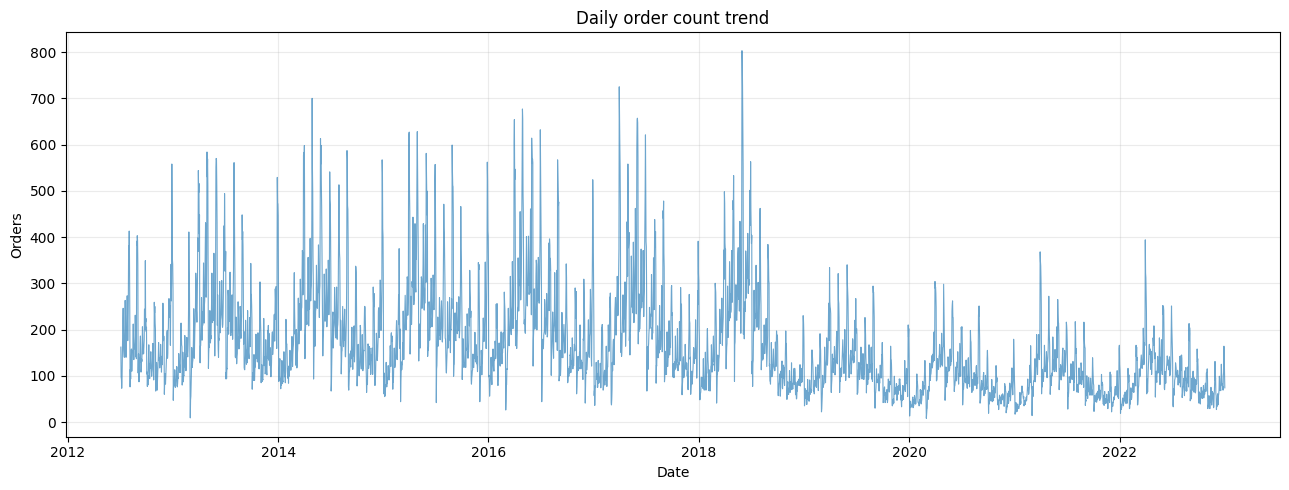

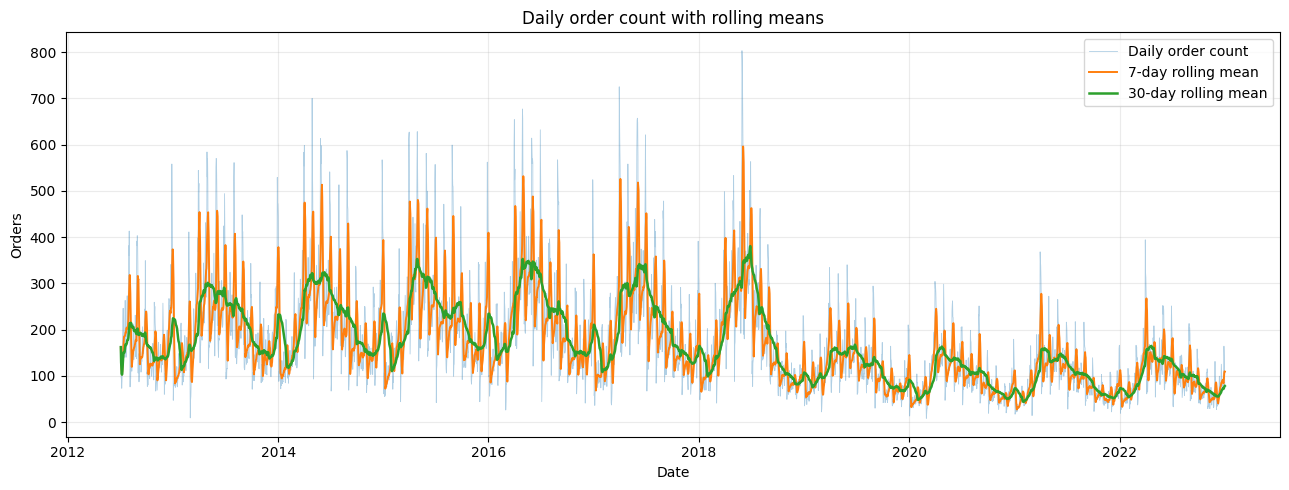

Order volume trend: decreasing based on 30-day rolling order count (182.6 early vs 67.4 recent, -63.1%)


In [7]:
volume_trend_statement = "not available"

if not daily_ts.empty:
    daily_ts["order_count_roll_mean_7_descriptive"] = daily_ts["order_count"].rolling(7, min_periods=1).mean()
    daily_ts["order_count_roll_mean_30_descriptive"] = daily_ts["order_count"].rolling(30, min_periods=1).mean()

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(daily_ts.index, daily_ts["order_count"], linewidth=0.8, alpha=0.65)
    ax.set_title("Daily order count trend")
    ax.set_xlabel("Date")
    ax.set_ylabel("Orders")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(daily_ts.index, daily_ts["order_count"], linewidth=0.6, alpha=0.35, label="Daily order count")
    ax.plot(daily_ts.index, daily_ts["order_count_roll_mean_7_descriptive"], linewidth=1.4, label="7-day rolling mean")
    ax.plot(daily_ts.index, daily_ts["order_count_roll_mean_30_descriptive"], linewidth=1.8, label="30-day rolling mean")
    ax.set_title("Daily order count with rolling means")
    ax.set_xlabel("Date")
    ax.set_ylabel("Orders")
    ax.legend()
    plt.tight_layout()
    plt.show()

    first_window = daily_ts["order_count_roll_mean_30_descriptive"].dropna().head(90).mean()
    last_window = daily_ts["order_count_roll_mean_30_descriptive"].dropna().tail(90).mean()
    if np.isfinite(first_window) and np.isfinite(last_window):
        pct_change = (last_window - first_window) / first_window if first_window != 0 else np.nan
        if not np.isfinite(pct_change) or abs(pct_change) < 0.05:
            volume_trend_statement = f"roughly stable based on 30-day rolling order count ({first_window:.1f} early vs {last_window:.1f} recent)"
        elif pct_change > 0:
            volume_trend_statement = f"increasing based on 30-day rolling order count ({first_window:.1f} early vs {last_window:.1f} recent, {pct_change:.1%})"
        else:
            volume_trend_statement = f"decreasing based on 30-day rolling order count ({first_window:.1f} early vs {last_window:.1f} recent, {pct_change:.1%})"
    print(f"Order volume trend: {volume_trend_statement}")
else:
    display_warning("Daily order count trend skipped because daily time series is unavailable.")

## 8. Revenue versus order count relationship

Daily revenue is compared with daily order count and AOV. Correlations are descriptive and should not be interpreted as causal effects.

,relationship,correlation
0,daily order count vs daily revenue,0.9359
1,daily AOV vs daily revenue,-0.0730
2,daily order count vs daily AOV,-0.3578


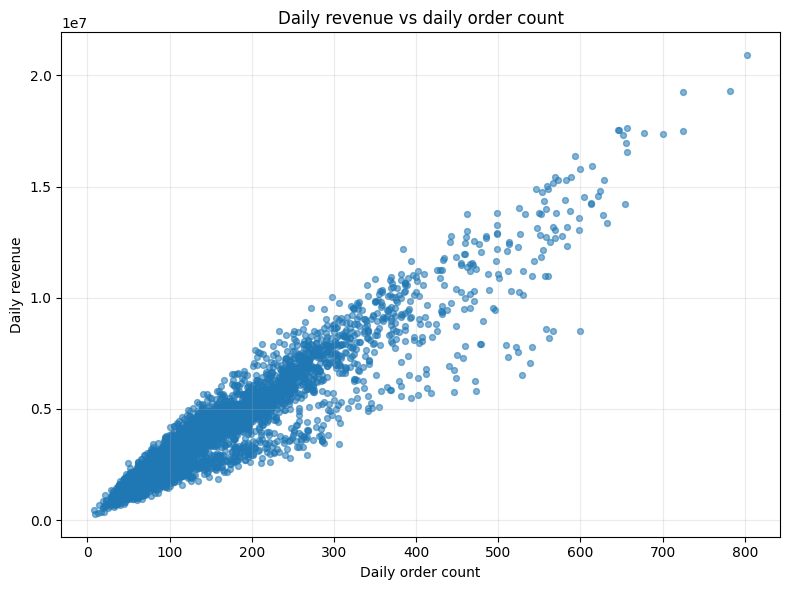

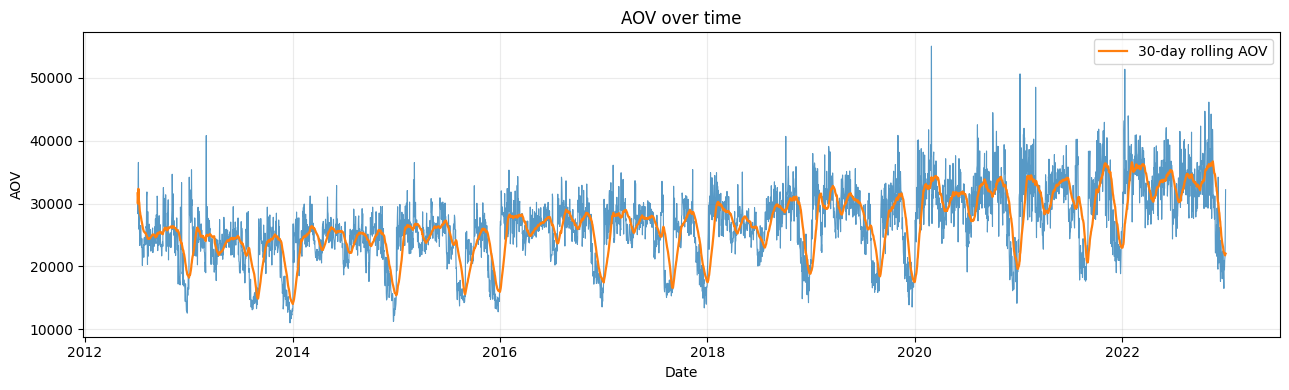

revenue variation appears more associated with order count (corr 0.936) than AOV (corr -0.073)


In [8]:
correlation_table = pd.DataFrame()
revenue_driver_statement = "not available"

if not daily_ts.empty and daily_ts["total_revenue"].notna().any():
    corr_data = daily_ts[["order_count", "total_revenue", "AOV"]].replace([np.inf, -np.inf], np.nan)
    correlation_table = pd.DataFrame(
        [
            {"relationship": "daily order count vs daily revenue", "correlation": corr_data["order_count"].corr(corr_data["total_revenue"])},
            {"relationship": "daily AOV vs daily revenue", "correlation": corr_data["AOV"].corr(corr_data["total_revenue"])},
            {"relationship": "daily order count vs daily AOV", "correlation": corr_data["order_count"].corr(corr_data["AOV"])},
        ]
    )
    display(correlation_table)

    volume_corr = correlation_table.loc[correlation_table["relationship"] == "daily order count vs daily revenue", "correlation"].iloc[0]
    aov_corr = correlation_table.loc[correlation_table["relationship"] == "daily AOV vs daily revenue", "correlation"].iloc[0]
    if abs(volume_corr) > abs(aov_corr) + 0.05:
        revenue_driver_statement = f"revenue variation appears more associated with order count (corr {volume_corr:.3f}) than AOV (corr {aov_corr:.3f})"
    elif abs(aov_corr) > abs(volume_corr) + 0.05:
        revenue_driver_statement = f"revenue variation appears more associated with AOV (corr {aov_corr:.3f}) than order count (corr {volume_corr:.3f})"
    else:
        revenue_driver_statement = f"revenue variation appears similarly associated with order count (corr {volume_corr:.3f}) and AOV (corr {aov_corr:.3f})"

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(daily_ts["order_count"], daily_ts["total_revenue"], alpha=0.55, s=18)
    ax.set_title("Daily revenue vs daily order count")
    ax.set_xlabel("Daily order count")
    ax.set_ylabel("Daily revenue")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(daily_ts.index, daily_ts["AOV"], linewidth=0.8, alpha=0.75)
    ax.plot(daily_ts.index, daily_ts["AOV"].rolling(30, min_periods=1).mean(), linewidth=1.6, label="30-day rolling AOV")
    ax.set_title("AOV over time")
    ax.set_xlabel("Date")
    ax.set_ylabel("AOV")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(revenue_driver_statement)
else:
    display_warning("Revenue versus order count analysis skipped because daily revenue is unavailable.")

## 9. Monthly orders versus monthly revenue

Monthly order count, revenue, and AOV are compared to inspect whether monthly revenue growth aligns with order-volume growth.

,month,monthly_order_count,monthly_revenue,monthly_quantity,monthly_AOV,order_count_pct_change,revenue_pct_change,AOV_pct_change
102,2021-01-01,1372,"46,473,094.4200",6577,"33,872.5178",-0.3783,0.0641,0.7118
103,2021-02-01,1976,"66,077,638.5700",9516,"33,440.1005",0.4402,0.4218,-0.0128
104,2021-03-01,4006,"113,274,006.6300",19186,"28,276.0875",1.0273,0.7143,-0.1544
105,2021-04-01,4346,"134,836,887.5300",20753,"31,025.5148",0.0849,0.1904,0.0972
106,2021-05-01,4267,"143,070,694.8700",20223,"33,529.5746",-0.0182,0.0611,0.0807
107,2021-06-01,3963,"128,449,576.2600",18404,"32,412.2070",-0.0712,-0.1022,-0.0333
108,2021-07-01,3292,"101,001,502.3000",15239,"30,680.8938",-0.1693,-0.2137,-0.0534
109,2021-08-01,3225,"68,280,026.8200",15181,"21,172.1013",-0.0204,-0.3240,-0.3099
110,2021-09-01,2431,"74,841,850.2600",11488,"30,786.4460",-0.2462,0.0961,0.4541
111,2021-10-01,1831,"65,692,136.1600",8881,"35,877.7368",-0.2468,-0.1223,0.1654


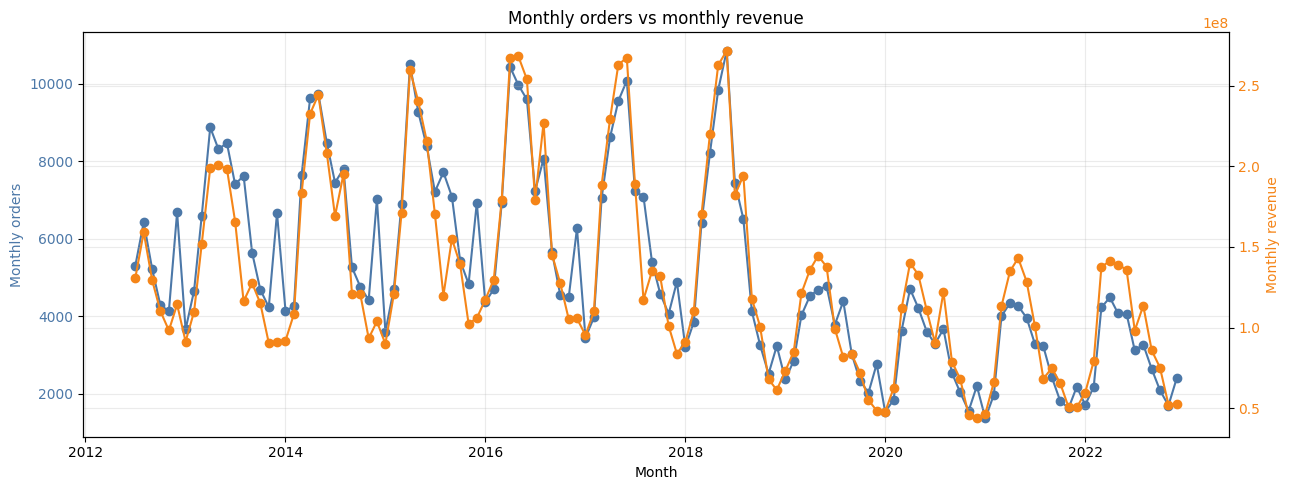

,month,monthly_order_count,monthly_revenue,monthly_AOV,order_count_pct_change,revenue_pct_change,AOV_pct_change,pattern
96,2020-07-01,3293,"90,701,640.3800","27,543.7718",-0.0876,-0.1800,-0.1013,both orders and revenue decreased
97,2020-08-01,3674,"122,065,017.3600","33,224.0113",0.1157,0.3458,0.2062,both orders and revenue increased
98,2020-09-01,2543,"78,825,813.7000","30,997.1741",-0.3078,-0.3542,-0.0670,both orders and revenue decreased
99,2020-10-01,2042,"68,136,462.9300","33,367.5137",-0.1970,-0.1356,0.0765,both orders and revenue decreased
100,2020-11-01,1563,"45,740,881.4500","29,264.7994",-0.2346,-0.3287,-0.1230,both orders and revenue decreased
101,2020-12-01,2207,"43,671,563.7700","19,787.7498",0.4120,-0.0452,-0.3238,orders increased but revenue did not increase ...
102,2021-01-01,1372,"46,473,094.4200","33,872.5178",-0.3783,0.0641,0.7118,mixed or stable
103,2021-02-01,1976,"66,077,638.5700","33,440.1005",0.4402,0.4218,-0.0128,both orders and revenue increased
104,2021-03-01,4006,"113,274,006.6300","28,276.0875",1.0273,0.7143,-0.1544,both orders and revenue increased
105,2021-04-01,4346,"134,836,887.5300","31,025.5148",0.0849,0.1904,0.0972,both orders and revenue increased


monthly revenue and monthly order count correlation is 0.925


In [9]:
monthly_ts = pd.DataFrame()
monthly_alignment_statement = "not available"

if not daily_ts.empty:
    monthly_ts = daily_ts.groupby("month").agg(
        monthly_order_count=("order_count", "sum"),
        monthly_revenue=("total_revenue", "sum"),
        monthly_quantity=("total_quantity", "sum"),
    ).reset_index()
    monthly_ts["monthly_AOV"] = monthly_ts["monthly_revenue"] / monthly_ts["monthly_order_count"].replace(0, np.nan)
    monthly_ts["order_count_pct_change"] = monthly_ts["monthly_order_count"].pct_change()
    monthly_ts["revenue_pct_change"] = monthly_ts["monthly_revenue"].pct_change()
    monthly_ts["AOV_pct_change"] = monthly_ts["monthly_AOV"].pct_change()
    display(monthly_ts.tail(24))

    if len(monthly_ts) >= 3:
        monthly_corr = monthly_ts["monthly_order_count"].corr(monthly_ts["monthly_revenue"])
        monthly_alignment_statement = f"monthly revenue and monthly order count correlation is {monthly_corr:.3f}"

    fig, ax1 = plt.subplots(figsize=(13, 5))
    ax1.plot(monthly_ts["month"], monthly_ts["monthly_order_count"], color="#4C78A8", marker="o", label="Monthly orders")
    ax1.set_xlabel("Month")
    ax1.set_ylabel("Monthly orders", color="#4C78A8")
    ax1.tick_params(axis="y", labelcolor="#4C78A8")
    ax2 = ax1.twinx()
    ax2.plot(monthly_ts["month"], monthly_ts["monthly_revenue"], color="#F58518", marker="o", label="Monthly revenue")
    ax2.set_ylabel("Monthly revenue", color="#F58518")
    ax2.tick_params(axis="y", labelcolor="#F58518")
    ax1.set_title("Monthly orders vs monthly revenue")
    plt.tight_layout()
    plt.show()

    monthly_flags = monthly_ts.copy()
    monthly_flags["pattern"] = np.select(
        [
            (monthly_flags["order_count_pct_change"] > 0.05) & (monthly_flags["revenue_pct_change"] <= 0.05),
            (monthly_flags["revenue_pct_change"] > 0.05) & (monthly_flags["order_count_pct_change"].abs() <= 0.05),
            (monthly_flags["order_count_pct_change"] > 0.05) & (monthly_flags["revenue_pct_change"] > 0.05),
            (monthly_flags["order_count_pct_change"] < -0.05) & (monthly_flags["revenue_pct_change"] < -0.05),
        ],
        [
            "orders increased but revenue did not increase much",
            "revenue increased despite stable order count",
            "both orders and revenue increased",
            "both orders and revenue decreased",
        ],
        default="mixed or stable",
    )
    display(monthly_flags[["month", "monthly_order_count", "monthly_revenue", "monthly_AOV", "order_count_pct_change", "revenue_pct_change", "AOV_pct_change", "pattern"]].tail(30))
    print(monthly_alignment_statement)
else:
    display_warning("Monthly analysis skipped because daily time series is unavailable.")

## 10. High-revenue day decomposition

Top revenue days are classified by whether they look volume-driven, AOV-driven, both, or mixed based on order-count and AOV percentiles.

In [10]:
high_revenue_days = pd.DataFrame()

def percentile_rank(series):
    return series.rank(pct=True, method="average")

def classify_high_revenue_day(order_pct, aov_pct):
    if pd.isna(order_pct) or pd.isna(aov_pct):
        return "unclear/missing"
    if order_pct >= 0.90 and aov_pct >= 0.90:
        return "both high order count and high AOV"
    if order_pct >= 0.90 and aov_pct < 0.75:
        return "unusually high order count"
    if aov_pct >= 0.90 and order_pct < 0.75:
        return "unusually high AOV"
    if order_pct >= 0.90:
        return "order count leaning"
    if aov_pct >= 0.90:
        return "AOV leaning"
    return "unclear/mixed"

if not daily_ts.empty:
    day_rank = daily_ts[["order_count", "total_revenue", "AOV"]].copy()
    day_rank["order_count_percentile"] = percentile_rank(day_rank["order_count"])
    day_rank["AOV_percentile"] = percentile_rank(day_rank["AOV"])
    top_n = min(25, len(day_rank))
    high_revenue_days = day_rank.sort_values("total_revenue", ascending=False).head(top_n).reset_index()
    high_revenue_days["driver_classification"] = [
        classify_high_revenue_day(o, a) for o, a in zip(high_revenue_days["order_count_percentile"], high_revenue_days["AOV_percentile"])
    ]
    display(high_revenue_days)

    class_counts = high_revenue_days["driver_classification"].value_counts().rename_axis("driver_classification").reset_index(name="top_revenue_days")
    display(class_counts)
else:
    display_warning("High-revenue day decomposition skipped because daily time series is unavailable.")

,date,order_count,total_revenue,AOV,order_count_percentile,AOV_percentile,driver_classification
0,2018-05-30,803,"20,905,271.3500","26,033.9618",1.0000,0.4443,unusually high order count
1,2018-05-31,782,"19,289,944.1200","24,667.4477",0.9997,0.3376,unusually high order count
2,2018-06-01,725,"19,245,165.7800","26,545.0562",0.9993,0.4863,unusually high order count
3,2017-06-01,657,"17,639,270.8800","26,848.2053",0.9984,0.5116,unusually high order count
4,2018-06-02,646,"17,529,108.3400","27,134.8426",0.9969,0.5325,unusually high order count
5,2017-06-02,647,"17,528,852.8800","27,092.5083",0.9971,0.5301,unusually high order count
6,2017-03-30,725,"17,516,038.8200","24,160.0535",0.9993,0.3024,unusually high order count
7,2016-04-28,677,"17,388,183.1900","25,684.1701",0.9987,0.4156,unusually high order count
8,2014-04-29,700,"17,347,427.2700","24,782.0390",0.9990,0.3459,unusually high order count
9,2017-05-31,652,"17,314,841.8600","26,556.5059",0.9974,0.4879,unusually high order count


,driver_classification,top_revenue_days
0,unusually high order count,25


## 11. Order-count anomaly detection

Unusually high and low order-volume days are detected with interpretable z-score, IQR, and percentile checks. These are exploratory flags.

In [11]:
order_count_anomalies = pd.DataFrame()
high_volume_days = pd.DataFrame()
low_volume_days = pd.DataFrame()

if not daily_ts.empty:
    counts = daily_ts["order_count"]
    mean_count = counts.mean()
    std_count = counts.std(ddof=0)
    q1 = counts.quantile(0.25)
    q3 = counts.quantile(0.75)
    iqr = q3 - q1
    high_iqr = q3 + 1.5 * iqr
    low_iqr = max(0, q1 - 1.5 * iqr)
    high_pct = counts.quantile(0.99)
    low_pct = counts.quantile(0.01)

    anomaly_df = daily_ts[["order_count", "total_revenue", "AOV"]].copy()
    anomaly_df["order_count_zscore"] = (anomaly_df["order_count"] - mean_count) / std_count if std_count else np.nan
    anomaly_df["is_high_order_volume"] = (anomaly_df["order_count_zscore"] >= 3) | (anomaly_df["order_count"] >= high_iqr) | (anomaly_df["order_count"] >= high_pct)
    anomaly_df["is_low_order_volume"] = (anomaly_df["order_count_zscore"] <= -3) | (anomaly_df["order_count"] <= low_iqr) | (anomaly_df["order_count"] <= low_pct)
    anomaly_df["high_revenue_day"] = anomaly_df["total_revenue"] >= anomaly_df["total_revenue"].quantile(0.95)
    order_count_anomalies = anomaly_df[anomaly_df["is_high_order_volume"] | anomaly_df["is_low_order_volume"]].reset_index()
    high_volume_days = order_count_anomalies[order_count_anomalies["is_high_order_volume"]].sort_values("order_count", ascending=False)
    low_volume_days = order_count_anomalies[order_count_anomalies["is_low_order_volume"]].sort_values("order_count", ascending=True)

    print("High order-volume anomaly days:")
    display(high_volume_days.head(20))
    print("Low order-volume anomaly days:")
    display(low_volume_days.head(20))

    if len(high_volume_days) > 0:
        overlap_share = high_volume_days["high_revenue_day"].mean()
        print(f"Share of high order-volume anomaly days that are also top-5% revenue days: {overlap_share:.1%}")
else:
    display_warning("Order-count anomaly detection skipped because daily time series is unavailable.")

High order-volume anomaly days:


,date,order_count,total_revenue,AOV,order_count_zscore,is_high_order_volume,is_low_order_volume,high_revenue_day
152,2018-05-30,803,"20,905,271.3500","26,033.9618",5.7115,True,False,True
153,2018-05-31,782,"19,289,944.1200","24,667.4477",5.5224,True,False,True
121,2017-03-30,725,"17,516,038.8200","24,160.0535",5.0091,True,False,True
154,2018-06-01,725,"19,245,165.7800","26,545.0562",5.0091,True,False,True
37,2014-04-29,700,"17,347,427.2700","24,782.0390",4.7839,True,False,True
100,2016-04-28,677,"17,388,183.1900","25,684.1701",4.5768,True,False,True
133,2017-06-01,657,"17,639,270.8800","26,848.2053",4.3967,True,False,True
122,2017-03-31,656,"16,556,662.0300","25,238.8141",4.3877,True,False,True
101,2016-04-29,655,"16,966,030.5000","25,902.3366",4.3787,True,False,True
93,2016-03-31,654,"14,231,299.7300","21,760.3971",4.3697,True,False,True


Low order-volume anomaly days:


,date,order_count,total_revenue,AOV,order_count_zscore,is_high_order_volume,is_low_order_volume,high_revenue_day
172,2020-02-29,8,"440,505.0800","55,063.1350",-1.4479,False,True,False
4,2013-03-02,9,"279,813.9400","31,090.4378",-1.4389,False,True,False
169,2020-01-02,13,"306,693.8700","23,591.8362",-1.4029,False,True,False
189,2021-03-02,14,"679,248.3700","48,517.7407",-1.3939,False,True,False
181,2021-01-02,17,"378,420.4100","22,260.0241",-1.3669,False,True,False
194,2022-01-03,19,"545,563.7200","28,713.8800",-1.3489,False,True,False
176,2020-10-02,19,"844,947.1200","44,470.9011",-1.3489,False,True,False
173,2020-03-01,19,"574,193.4200","30,220.7063",-1.3489,False,True,False
178,2020-12-02,20,"370,653.2300","18,532.6615",-1.3399,False,True,False
182,2021-01-03,22,"677,894.5600","30,813.3891",-1.3219,False,True,False


Share of high order-volume anomaly days that are also top-5% revenue days: 76.8%


## 12. Seasonality comparison between order count and revenue

Average order count and average revenue are compared by month of year, day of week, and quarter to see whether volume seasonality resembles revenue seasonality.

Month-of-year seasonality:


,month_of_year,avg_order_count,avg_revenue,avg_AOV,days
0,1,95.0000,"2,591,154.6045","29,001.1098",310
1,2,124.2234,"3,480,800.7782","29,300.0666",282
2,3,185.2903,"4,928,185.4732","28,247.9365",310
3,4,247.7833,"6,532,951.8821","27,303.0960",300
4,5,238.5258,"6,575,416.3495","28,759.3788",310
5,6,240.9000,"6,427,108.6523","28,205.8226",300
6,7,185.7278,"4,659,789.3747","26,124.0408",338
7,8,192.9941,"4,441,193.4900","23,933.1782",341
8,9,148.6485,"3,797,825.6016","27,056.4586",330
9,10,117.0176,"3,302,725.2192","29,777.9340",341


Day-of-week seasonality:


,dayofweek,weekday_name,avg_order_count,avg_revenue,avg_AOV,days
0,0,Monday,169.9890,"4,311,034.6027","26,675.8735",547
1,1,Tuesday,176.9525,"4,465,102.6433","26,581.3496",547
2,2,Wednesday,184.4270,"4,680,064.8379","26,732.7208",548
3,3,Thursday,177.1989,"4,523,044.0528","26,841.0027",548
4,4,Friday,158.7810,"4,046,389.7347","26,902.1876",548
5,5,Saturday,153.1953,"3,906,580.8389","26,873.7197",548
6,6,Sunday,160.9397,"4,073,853.6848","26,671.0540",547


Quarter seasonality:


,quarter,avg_order_count,avg_revenue,avg_AOV,days
0,1,135.1674,"3,672,484.7489","28,835.7241",902
1,2,242.3604,"6,512,524.4271","28,096.7945",910
2,3,176.0565,"4,304,002.2173","25,688.5738",1009
3,4,125.3310,"2,814,980.1147","24,753.6445",1012


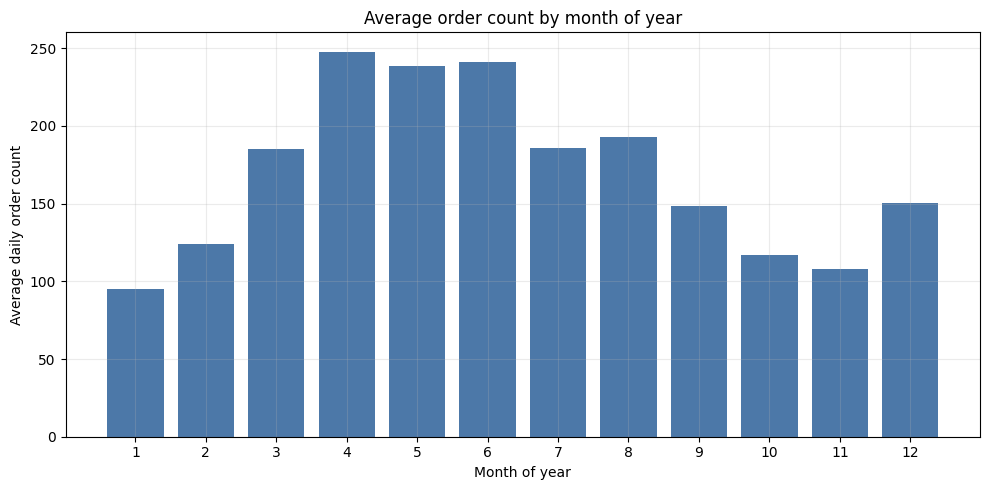

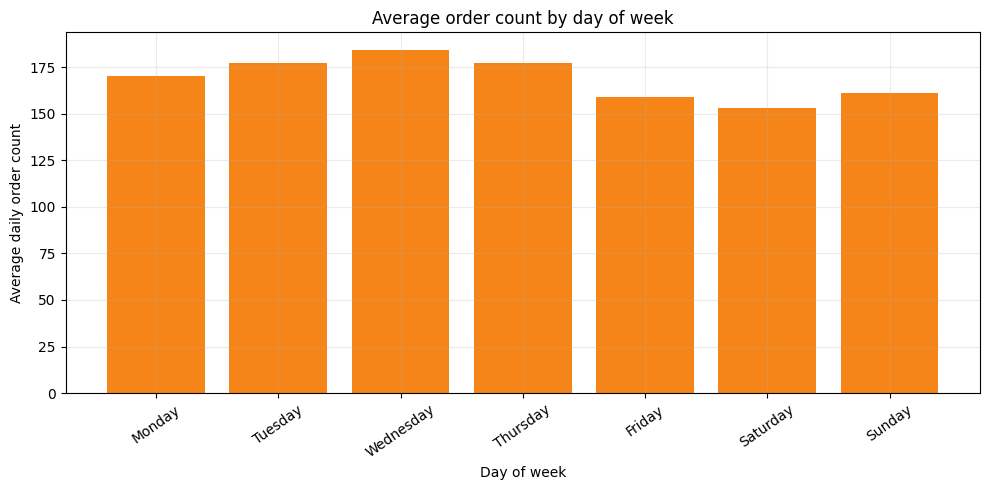

order-count seasonality appears similar to revenue seasonality (month corr 0.950, weekday corr 0.998, quarter corr 0.985)


In [12]:
month_seasonality = pd.DataFrame()
dow_seasonality = pd.DataFrame()
quarter_seasonality = pd.DataFrame()
seasonality_statement = "not available"

if not daily_ts.empty:
    month_seasonality = daily_ts.groupby("month_of_year").agg(
        avg_order_count=("order_count", "mean"),
        avg_revenue=("total_revenue", "mean"),
        avg_AOV=("AOV", "mean"),
        days=("order_count", "size"),
    ).reset_index()
    dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    dow_seasonality = daily_ts.groupby(["dayofweek", "weekday_name"]).agg(
        avg_order_count=("order_count", "mean"),
        avg_revenue=("total_revenue", "mean"),
        avg_AOV=("AOV", "mean"),
        days=("order_count", "size"),
    ).reset_index().sort_values("dayofweek")
    quarter_seasonality = daily_ts.groupby("quarter").agg(
        avg_order_count=("order_count", "mean"),
        avg_revenue=("total_revenue", "mean"),
        avg_AOV=("AOV", "mean"),
        days=("order_count", "size"),
    ).reset_index()

    month_corr = month_seasonality["avg_order_count"].corr(month_seasonality["avg_revenue"])
    dow_corr = dow_seasonality["avg_order_count"].corr(dow_seasonality["avg_revenue"])
    quarter_corr = quarter_seasonality["avg_order_count"].corr(quarter_seasonality["avg_revenue"])
    if np.nanmean([month_corr, dow_corr, quarter_corr]) >= 0.8:
        seasonality_statement = f"order-count seasonality appears similar to revenue seasonality (month corr {month_corr:.3f}, weekday corr {dow_corr:.3f}, quarter corr {quarter_corr:.3f})"
    elif np.nanmean([month_corr, dow_corr, quarter_corr]) >= 0.5:
        seasonality_statement = f"order-count seasonality is moderately similar to revenue seasonality (month corr {month_corr:.3f}, weekday corr {dow_corr:.3f}, quarter corr {quarter_corr:.3f})"
    else:
        seasonality_statement = f"order-count seasonality differs from revenue seasonality (month corr {month_corr:.3f}, weekday corr {dow_corr:.3f}, quarter corr {quarter_corr:.3f})"

    print("Month-of-year seasonality:")
    display(month_seasonality)
    print("Day-of-week seasonality:")
    display(dow_seasonality)
    print("Quarter seasonality:")
    display(quarter_seasonality)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(month_seasonality["month_of_year"].astype(str), month_seasonality["avg_order_count"], color="#4C78A8")
    ax.set_title("Average order count by month of year")
    ax.set_xlabel("Month of year")
    ax.set_ylabel("Average daily order count")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(dow_seasonality["weekday_name"], dow_seasonality["avg_order_count"], color="#F58518")
    ax.set_title("Average order count by day of week")
    ax.set_xlabel("Day of week")
    ax.set_ylabel("Average daily order count")
    ax.tick_params(axis="x", rotation=35)
    plt.tight_layout()
    plt.show()

    print(seasonality_statement)
else:
    display_warning("Seasonality comparison skipped because daily time series is unavailable.")

## 13. Leakage-safe order-count forecast feature preview

Forecast candidate features use only historical order count and AOV values. The current day's order count is not used to compute that same day's forecast feature.

In [13]:
feature_preview = pd.DataFrame()

if not daily_ts.empty:
    feature_preview = pd.DataFrame(index=daily_ts.index)
    feature_preview["total_revenue"] = daily_ts["total_revenue"]
    feature_preview["order_count"] = daily_ts["order_count"]
    feature_preview["AOV"] = daily_ts["AOV"]

    shifted_orders = daily_ts["order_count"].shift(1)
    shifted_aov = daily_ts["AOV"].shift(1)
    feature_preview["order_count_lag_1"] = daily_ts["order_count"].shift(1)
    feature_preview["order_count_lag_7"] = daily_ts["order_count"].shift(7)
    feature_preview["order_count_lag_30"] = daily_ts["order_count"].shift(30)
    feature_preview["order_count_roll_mean_7"] = shifted_orders.rolling(7, min_periods=3).mean()
    feature_preview["order_count_roll_mean_30"] = shifted_orders.rolling(30, min_periods=7).mean()
    feature_preview["order_count_roll_std_30"] = shifted_orders.rolling(30, min_periods=7).std()
    feature_preview["aov_lag_1"] = daily_ts["AOV"].shift(1)
    feature_preview["aov_lag_7"] = daily_ts["AOV"].shift(7)
    feature_preview["aov_roll_mean_30"] = shifted_aov.rolling(30, min_periods=7).mean()
    feature_preview = feature_preview.reset_index().rename(columns={"index": "date"})

    print("Feature preview. Lag and rolling features are shifted so date t uses only dates before t.")
    display(feature_preview.head(40))
else:
    display_warning("Feature preview skipped because daily time series is unavailable.")

Feature preview. Lag and rolling features are shifted so date t uses only dates before t.


,date,total_revenue,order_count,AOV,order_count_lag_1,order_count_lag_7,order_count_lag_30,order_count_roll_mean_7,order_count_roll_mean_30,order_count_roll_std_30,aov_lag_1,aov_lag_7,aov_roll_mean_30
0,2012-07-04,"5,123,547.9400",162,"31,626.8391",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-05,"2,751,773.4500",97,"28,368.7985",162.0000,NaN,NaN,NaN,NaN,NaN,"31,626.8391",NaN,NaN
2,2012-07-06,"3,054,029.4200",93,"32,839.0260",97.0000,NaN,NaN,NaN,NaN,NaN,"28,368.7985",NaN,NaN
3,2012-07-07,"2,667,930.9400",73,"36,546.9992",93.0000,NaN,NaN,117.3333,NaN,NaN,"32,839.0260",NaN,NaN
4,2012-07-08,"2,360,851.9000",88,"26,827.8625",73.0000,NaN,NaN,106.2500,NaN,NaN,"36,546.9992",NaN,NaN
5,2012-07-09,"3,548,386.4600",137,"25,900.6311",88.0000,NaN,NaN,102.6000,NaN,NaN,"26,827.8625",NaN,NaN
6,2012-07-10,"5,234,938.6200",183,"28,606.2220",137.0000,NaN,NaN,108.3333,NaN,NaN,"25,900.6311",NaN,NaN
7,2012-07-11,"5,582,884.7800",221,"25,261.9221",183.0000,162.0000,NaN,119.0000,119.0000,41.8450,"28,606.2220","31,626.8391","30,102.3398"
8,2012-07-12,"5,734,632.0200",246,"23,311.5123",221.0000,97.0000,NaN,127.4286,131.7500,52.9278,"25,261.9221","28,368.7985","29,497.2876"
9,2012-07-13,"5,309,511.7100",201,"26,415.4811",246.0000,93.0000,NaN,148.7143,144.4444,62.4622,"23,311.5123","32,839.0260","28,809.9792"


## 14. Key observations and warnings

This summary reports whether revenue appears more aligned with order count or AOV, where order-volume anomalies occur, and which leakage-safe features are reasonable candidates.

In [14]:
print("Concise insight summary")
print("=" * 80)

print(f"Revenue source used: {selected_revenue_source}. {selected_revenue_reason}")

if not correlation_table.empty:
    print(f"Revenue association: {revenue_driver_statement}.")
    corr_text = "; ".join(f"{row.relationship}: {row.correlation:.3f}" for row in correlation_table.itertuples(index=False))
    print(f"Correlation details: {corr_text}.")
else:
    print("Revenue association: not available because revenue or daily time series was unavailable.")

print(f"Order-count seasonality vs revenue seasonality: {seasonality_statement}.")
print(f"Monthly revenue/order growth alignment: {monthly_alignment_statement}.")
print(f"Order volume trend: {volume_trend_statement}.")

if not high_volume_days.empty:
    high_text = "; ".join(
        f"{row.date.date()} ({row.order_count:,.0f} orders, revenue {row.total_revenue:,.2f})"
        for row in high_volume_days.head(5).itertuples(index=False)
    )
    print(f"Periods with unusually high order volume: {high_text}.")
else:
    print("Periods with unusually high order volume: none flagged by the configured rules.")

if not low_volume_days.empty:
    low_text = "; ".join(
        f"{row.date.date()} ({row.order_count:,.0f} orders, revenue {row.total_revenue:,.2f})"
        for row in low_volume_days.head(5).itertuples(index=False)
    )
    print(f"Periods with unusually low order volume: {low_text}.")
else:
    print("Periods with unusually low order volume: none flagged by the configured rules.")

if not high_revenue_days.empty:
    order_driven = high_revenue_days[high_revenue_days["driver_classification"].str.contains("order count", case=False, na=False)]
    aov_driven = high_revenue_days[high_revenue_days["driver_classification"].str.contains("AOV", case=False, na=False)]
    if not order_driven.empty:
        text = "; ".join(
            f"{row.date.date()} ({row.total_revenue:,.2f}, {row.order_count:,.0f} orders, AOV {row.AOV:,.2f}, {row.driver_classification})"
            for row in order_driven.head(5).itertuples(index=False)
        )
        print(f"High-revenue days driven mainly by order count: {text}.")
    else:
        print("High-revenue days driven mainly by order count: none among the top revenue days by the percentile rules.")
    if not aov_driven.empty:
        text = "; ".join(
            f"{row.date.date()} ({row.total_revenue:,.2f}, {row.order_count:,.0f} orders, AOV {row.AOV:,.2f}, {row.driver_classification})"
            for row in aov_driven.head(5).itertuples(index=False)
        )
        print(f"High-revenue days driven mainly by AOV: {text}.")
    else:
        print("High-revenue days driven mainly by AOV: none among the top revenue days by the percentile rules.")
else:
    print("High-revenue day decomposition: not available.")

recommended_features = [
    "order_count_lag_1",
    "order_count_lag_7",
    "order_count_lag_30",
    "order_count_roll_mean_7",
    "order_count_roll_mean_30",
    "order_count_roll_std_30",
    "aov_lag_1",
    "aov_lag_7",
    "aov_roll_mean_30",
]
print("Recommended leakage-safe order-count forecast features: " + ", ".join(recommended_features) + ".")

quality_warnings = []
if quality:
    if quality.get("orders_without_selected_revenue", 0):
        quality_warnings.append(f"{quality['orders_without_selected_revenue']:,} orders without selected revenue")
    if quality.get("negative_revenue_orders", 0):
        quality_warnings.append(f"{quality['negative_revenue_orders']:,} negative-revenue orders")
    if quality.get("zero_revenue_orders", 0):
        quality_warnings.append(f"{quality['zero_revenue_orders']:,} zero-revenue orders")
    if quality.get("orders_with_invalid_dates_removed_from_daily_series", 0):
        quality_warnings.append(f"{quality['orders_with_invalid_dates_removed_from_daily_series']:,} orders with invalid dates")
if not pd.isna(missing_dates_count) and missing_dates_count > 0:
    quality_warnings.append(f"{missing_dates_count:,} calendar dates had no orders and were filled as zero-order days")
print("Warnings: " + ("; ".join(quality_warnings) if quality_warnings else "none material for detected order/date/revenue fields") + ".")
print("Forecasting warning: future order count must not be used directly as a revenue feature unless order count is separately forecasted. The preview features shift before rolling or lagging.")

Concise insight summary
Revenue source used: item-derived revenue. Item-level quantity, price, and discount fields were available and matched most orders.
Revenue association: revenue variation appears more associated with order count (corr 0.936) than AOV (corr -0.073).
Correlation details: daily order count vs daily revenue: 0.936; daily AOV vs daily revenue: -0.073; daily order count vs daily AOV: -0.358.
Order-count seasonality vs revenue seasonality: order-count seasonality appears similar to revenue seasonality (month corr 0.950, weekday corr 0.998, quarter corr 0.985).
Monthly revenue/order growth alignment: monthly revenue and monthly order count correlation is 0.925.
Order volume trend: decreasing based on 30-day rolling order count (182.6 early vs 67.4 recent, -63.1%).
Periods with unusually high order volume: 2018-05-30 (803 orders, revenue 20,905,271.35); 2018-05-31 (782 orders, revenue 19,289,944.12); 2017-03-30 (725 orders, revenue 17,516,038.82); 2018-06-01 (725 orders, 